# 20NG Benchmark Dashboard

Reviews results produced by `scripts/train.py` and `scripts/llm_classify.py`. Each run lives in `artifacts/<run_name>/` and contains:
- `metrics.json` — test metrics. Sklearn runs also include nested-CV summary; LLM runs include a per-run `llm` block (tag, summary fraction, parse-failure count, mean summary length).
- `classification_report.json` — per-class precision/recall/F1 on test
- `confusion_matrix.npy` + `target_names.json`
- `best_model.joblib` — only for sklearn runs (Pipeline refit on full train with best HPs)
- `config.yaml` — full hydra config used

The `kind` column distinguishes `nested_cv` (sklearn embed-then-classify) from `llm_zero_shot` (LLM-summarize-then-classify) runs.

In [9]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ARTIFACTS = Path('..') / 'artifacts'
sns.set_theme(context='notebook', style='whitegrid')

## Load all runs

In [10]:
def load_runs(artifacts_dir: Path) -> pd.DataFrame:
    rows = []
    for run_dir in sorted(p for p in artifacts_dir.iterdir() if p.is_dir()):
        if run_dir.name.startswith('_'):
            continue
        metrics_path = run_dir / 'metrics.json'
        if not metrics_path.exists():
            continue
        m = json.loads(metrics_path.read_text())

        # Sklearn runs have nested_cv + best_params + n_train.
        # LLM runs have an `llm` block instead; fields not present are NaN.
        cv = m.get('nested_cv', {}).get('summary', {})
        llm = m.get('llm', {})
        rows.append({
            'run': run_dir.name,
            'kind': m.get('kind', 'nested_cv'),
            'model': m['model'],
            'featurizer': m['featurizer'],
            'data': m['data'],
            'n_train': m.get('n_train'),
            'n_test': m.get('n_test'),
            'test_accuracy': m['test']['accuracy'],
            'test_f1_macro': m['test']['f1_macro'],
            'test_f1_weighted': m['test']['f1_weighted'],
            'cv_f1_macro_mean': cv.get('f1_macro', {}).get('mean', np.nan),
            'cv_f1_macro_std': cv.get('f1_macro', {}).get('std', np.nan),
            'cv_accuracy_mean': cv.get('accuracy', {}).get('mean', np.nan),
            'best_params': m.get('best_params'),
            # LLM-only columns; NaN for sklearn rows.
            'llm_tag': llm.get('tag'),
            'summary_fraction': llm.get('fraction', np.nan),
            'n_unparseable': llm.get('n_unparseable'),
            'mean_summary_words': llm.get('mean_summary_words', np.nan),
            'llm_elapsed_s': llm.get('elapsed_s', np.nan),
            'path': str(run_dir),
        })
    return pd.DataFrame(rows)

runs = load_runs(ARTIFACTS)
runs

,run,kind,model,featurizer,data,n_train,n_test,test_accuracy,test_f1_macro,test_f1_weighted,cv_f1_macro_mean,cv_f1_macro_std,cv_accuracy_mean,best_params,llm_tag,summary_fraction,n_unparseable,mean_summary_words,llm_elapsed_s,path
0,complement_nb_tfidf_20ng,nested_cv,complement_nb,tfidf,20ng,15076.0,3770,0.780902,0.767968,0.778907,0.757403,0.010939,0.770363,"{'clf__alpha': 0.1, 'clf__norm': True, 'tfidf_...",NaN,NaN,NaN,NaN,NaN,../artifacts/complement_nb_tfidf_20ng
1,linear_svm_bge_small_20ng,nested_cv,linear_svm,bge_small,20ng,15076.0,3770,0.742175,0.725632,0.737668,0.711295,0.008393,0.728243,{'clf__C': 1.0},NaN,NaN,NaN,NaN,NaN,../artifacts/linear_svm_bge_small_20ng
2,linear_svm_tfidf_20ng,nested_cv,linear_svm,tfidf,20ng,15076.0,3770,0.782759,0.773886,0.782194,0.750593,0.007181,0.759353,"{'clf__C': 1.0, 'tfidf__min_df': 2, 'tfidf__ng...",NaN,NaN,NaN,NaN,NaN,../artifacts/linear_svm_tfidf_20ng
3,logreg_bge_small_20ng,nested_cv,logreg,bge_small,20ng,15076.0,3770,0.744297,0.732450,0.742748,0.712162,0.006074,0.724330,{'clf__C': 10.0},NaN,NaN,NaN,NaN,NaN,../artifacts/logreg_bge_small_20ng
4,logreg_tfidf_20ng,nested_cv,logreg,tfidf,20ng,15076.0,3770,0.775332,0.766911,0.775166,0.740969,0.007002,0.749337,"{'clf__C': 10.0, 'tfidf__min_df': 2, 'tfidf__n...",NaN,NaN,NaN,NaN,NaN,../artifacts/logreg_tfidf_20ng
5,nb_tfidf_20ng,nested_cv,nb,tfidf,20ng,15076.0,3770,0.771618,0.759736,0.768182,0.743903,0.008106,0.753118,"{'clf__alpha': 0.01, 'tfidf__min_df': 2, 'tfid...",NaN,NaN,NaN,NaN,NaN,../artifacts/nb_tfidf_20ng
6,qwen25_7b_summary0.25_20ng,llm_zero_shot,qwen25_7b,llm_summary_0.25,20ng,NaN,5,0.400000,0.250000,0.400000,NaN,NaN,NaN,None,qwen2.5:7b-instruct,0.25,0.0,26.4,860.454119,../artifacts/qwen25_7b_summary0.25_20ng
7,random_forest_bge_small_20ng,nested_cv,random_forest,bge_small,20ng,15076.0,3770,0.718833,0.694200,0.709202,0.674990,0.003776,0.699588,"{'clf__max_features': 'sqrt', 'clf__min_sample...",NaN,NaN,NaN,NaN,NaN,../artifacts/random_forest_bge_small_20ng


## Leaderboard

In [11]:
leaderboard = runs.sort_values('test_f1_macro', ascending=False)[[
    'run', 'kind', 'model', 'featurizer', 'cv_f1_macro_mean', 'cv_f1_macro_std',
    'test_f1_macro', 'test_accuracy'
]]
leaderboard

,run,kind,model,featurizer,cv_f1_macro_mean,cv_f1_macro_std,test_f1_macro,test_accuracy
2,linear_svm_tfidf_20ng,nested_cv,linear_svm,tfidf,0.750593,0.007181,0.773886,0.782759
0,complement_nb_tfidf_20ng,nested_cv,complement_nb,tfidf,0.757403,0.010939,0.767968,0.780902
4,logreg_tfidf_20ng,nested_cv,logreg,tfidf,0.740969,0.007002,0.766911,0.775332
5,nb_tfidf_20ng,nested_cv,nb,tfidf,0.743903,0.008106,0.759736,0.771618
3,logreg_bge_small_20ng,nested_cv,logreg,bge_small,0.712162,0.006074,0.732450,0.744297
1,linear_svm_bge_small_20ng,nested_cv,linear_svm,bge_small,0.711295,0.008393,0.725632,0.742175
7,random_forest_bge_small_20ng,nested_cv,random_forest,bge_small,0.674990,0.003776,0.694200,0.718833
6,qwen25_7b_summary0.25_20ng,llm_zero_shot,qwen25_7b,llm_summary_0.25,NaN,NaN,0.250000,0.400000


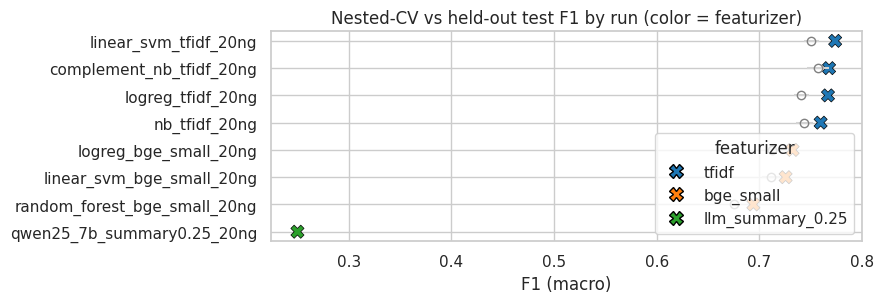

In [12]:
# CV vs test F1 by run, colored by featurizer.
# LLM runs have no nested-CV, so they show only the test marker (no errorbar).
feat_palette = dict(zip(
    leaderboard['featurizer'].unique(),
    sns.color_palette('tab10', n_colors=leaderboard['featurizer'].nunique()),
))
colors = leaderboard['featurizer'].map(feat_palette)
fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(leaderboard))))
y = np.arange(len(leaderboard))
has_cv = leaderboard['cv_f1_macro_mean'].notna()
ax.errorbar(leaderboard.loc[has_cv, 'cv_f1_macro_mean'], y[has_cv.values],
            xerr=leaderboard.loc[has_cv, 'cv_f1_macro_std'], fmt='o',
            ecolor='lightgray', mfc='none', mec='gray', label='Nested CV')
ax.scatter(leaderboard['test_f1_macro'], y, c=colors, marker='X', s=90,
           edgecolor='black', linewidth=0.5, label='Test')
ax.set_yticks(y, leaderboard['run'])
ax.invert_yaxis()
ax.set_xlabel('F1 (macro)')
ax.set_title('Nested-CV vs held-out test F1 by run (color = featurizer)')
handles = [plt.Line2D([], [], marker='X', linestyle='', color=c, label=f,
                      markeredgecolor='black', markersize=10)
           for f, c in feat_palette.items()]
ax.legend(handles=handles, title='featurizer', loc='lower right')
plt.tight_layout()

featurizer,bge_small,tfidf
model,,
complement_nb,NaN,0.7680
linear_svm,0.7256,0.7739
logreg,0.7325,0.7669
nb,NaN,0.7597
random_forest,0.6942,NaN


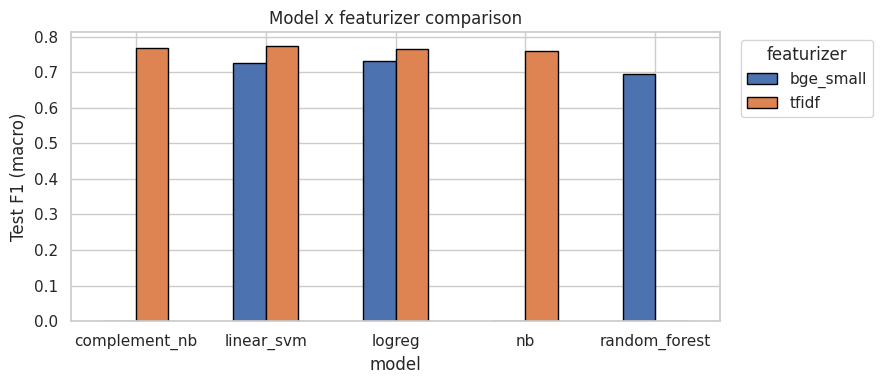

In [5]:
# Featurizer x model grid: held-out test F1 (macro)
if {'featurizer', 'model'}.issubset(runs.columns) and len(runs):
    pivot = (runs
             .pivot_table(index='model', columns='featurizer', values='test_f1_macro', aggfunc='max')
             .sort_index())
    display(pivot.round(4))
    ax = pivot.plot(kind='bar', figsize=(9, 4), edgecolor='black')
    ax.set_ylabel('Test F1 (macro)')
    ax.set_title('Model x featurizer comparison')
    ax.legend(title='featurizer', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()

## LLM summary-fraction sweep

For LLM zero-shot runs, plot test F1 (macro) vs. the summary length fraction. Horizontal lines show the best sklearn baselines for comparison.

In [ ]:
llm_runs = runs[runs['kind'] == 'llm_zero_shot'].copy()
if len(llm_runs):
    llm_runs = llm_runs.sort_values(['llm_tag', 'summary_fraction'])
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for tag, sub in llm_runs.groupby('llm_tag'):
        ax.plot(sub['summary_fraction'], sub['test_f1_macro'],
                marker='o', label=tag)
    # Best sklearn baseline overall, plus best per featurizer family.
    sk = runs[runs['kind'] == 'nested_cv']
    if len(sk):
        best = sk['test_f1_macro'].max()
        ax.axhline(best, color='black', linestyle='--', linewidth=1,
                   label=f'best sklearn (F1={best:.3f})')
    ax.set_xlabel('Summary length fraction')
    ax.set_ylabel('Test F1 (macro)')
    ax.set_title('LLM zero-shot: classification quality vs summary compression')
    ax.set_xlim(0, 1.05)
    ax.legend(loc='lower right')
    plt.tight_layout()

    cols = ['run', 'llm_tag', 'summary_fraction', 'mean_summary_words',
            'test_f1_macro', 'test_accuracy', 'n_unparseable', 'llm_elapsed_s']
    display(llm_runs[cols].round(4))
else:
    print('No LLM zero-shot runs found yet. Run scripts/llm_classify.py to produce some.')

In [ ]:
# Per-outer-fold breakdown (sklearn runs only — LLM runs have no nested CV).
if 'nested_cv' in metrics:
    fold_df = pd.DataFrame(metrics['nested_cv']['folds'])
    display(fold_df)
else:
    print(f"Run '{RUN}' is kind={metrics.get('kind')!r}; no nested-CV folds.")
    if 'llm' in metrics:
        display(pd.Series(metrics['llm']).rename('llm'))

In [6]:
RUN = runs.iloc[0]['run'] if len(runs) else None
run_dir = ARTIFACTS / RUN
metrics = json.loads((run_dir / 'metrics.json').read_text())
metrics

{'run_name': 'complement_nb_tfidf_20ng',
 'model': 'complement_nb',
 'featurizer': 'tfidf',
 'data': '20ng',
 'n_train': 15076,
 'n_test': 3770,
 'n_classes': 20,
 'best_params': {'clf__alpha': 0.1,
  'clf__norm': True,
  'tfidf__min_df': 2,
  'tfidf__ngram_range': [1, 2]},
 'best_inner_score': 0.7483946338909703,
 'nested_cv': {'folds': [{'fold': 0,
    'best_params': {'clf__alpha': 0.5,
     'clf__norm': False,
     'tfidf__min_df': 2,
     'tfidf__ngram_range': [1, 2]},
    'best_inner_score': 0.7397088078798421,
    'accuracy': 0.7705570291777188,
    'f1_macro': 0.7538765771538418,
    'f1_weighted': 0.7669584408078872},
   {'fold': 1,
    'best_params': {'clf__alpha': 0.5,
     'clf__norm': False,
     'tfidf__min_df': 2,
     'tfidf__ngram_range': [1, 2]},
    'best_inner_score': 0.7391172341920843,
    'accuracy': 0.7681592039800995,
    'f1_macro': 0.7563560976808167,
    'f1_weighted': 0.76616524899358},
   {'fold': 2,
    'best_params': {'clf__alpha': 0.5,
     'clf__norm': 

In [7]:
# Per-outer-fold breakdown
fold_df = pd.DataFrame(metrics['nested_cv']['folds'])
fold_df

,fold,best_params,best_inner_score,accuracy,f1_macro,f1_weighted
0,0,"{'clf__alpha': 0.5, 'clf__norm': False, 'tfidf...",0.739709,0.770557,0.753877,0.766958
1,1,"{'clf__alpha': 0.5, 'clf__norm': False, 'tfidf...",0.739117,0.768159,0.756356,0.766165
2,2,"{'clf__alpha': 0.5, 'clf__norm': False, 'tfidf...",0.734642,0.776451,0.763853,0.774299
3,3,"{'clf__alpha': 0.1, 'clf__norm': True, 'tfidf_...",0.732060,0.783085,0.772918,0.783189
4,4,"{'clf__alpha': 0.5, 'clf__norm': True, 'tfidf_...",0.739543,0.753566,0.740011,0.751904


In [ ]:
# Load the persisted sklearn Pipeline for ad-hoc inference.
# LLM runs do not have a best_model.joblib (they're zero-shot, no fit step).
joblib_path = run_dir / 'best_model.joblib'
if joblib_path.exists():
    model = joblib.load(joblib_path)
    display(model)
else:
    print(f"No best_model.joblib for '{RUN}' (kind={metrics.get('kind')!r}).")

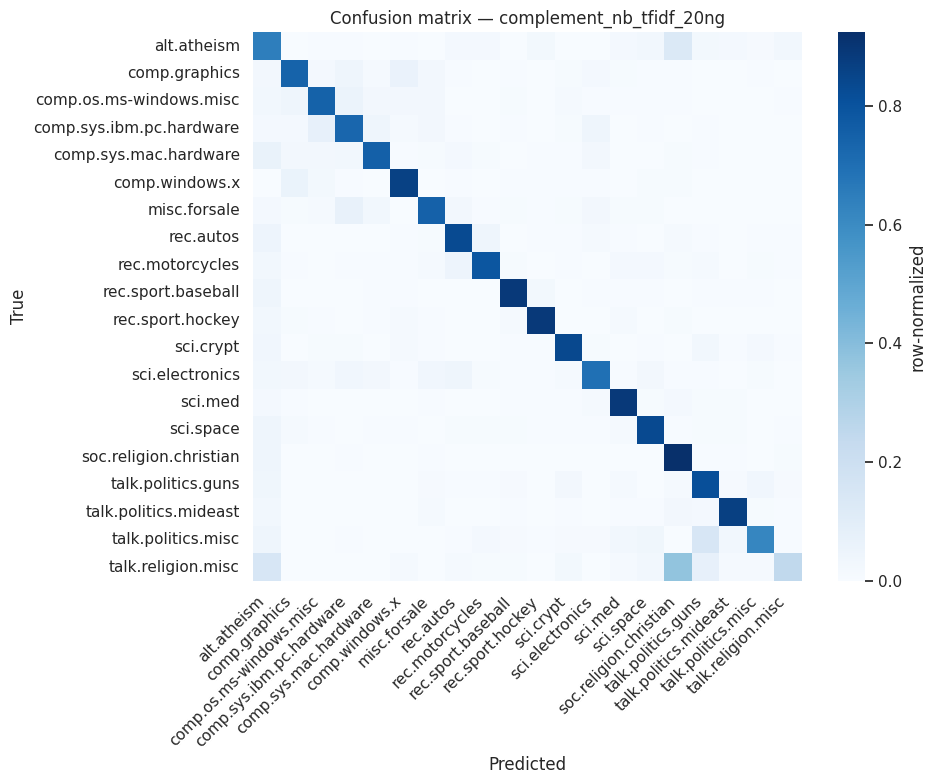

In [9]:
# Confusion matrix
cm = np.load(run_dir / 'confusion_matrix.npy')
target_names = json.loads((run_dir / 'target_names.json').read_text())
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm / cm.sum(axis=1, keepdims=True),
    xticklabels=target_names, yticklabels=target_names,
    cmap='Blues', square=True, cbar_kws={'label': 'row-normalized'}, ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion matrix — {RUN}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [10]:
# Load the persisted Pipeline for ad-hoc inference
model = joblib.load(run_dir / 'best_model.joblib')
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
